<a href="https://colab.research.google.com/github/TegarReskiPratama/House-Price-Prediction/blob/main/House_Prices_Advanced_Regression_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install xgboost

In [ ]:
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Model
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# Save Model
import joblib

# Style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


In [ ]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Random State :", RANDOM_STATE)

Random State : 42


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving house-prices-advanced-regression-techniques.zip to house-prices-advanced-regression-techniques.zip


In [ ]:
from zipfile import ZipFile
from pathlib import Path

zip_path = Path("/content/house-prices-advanced-regression-techniques.zip")
extract_dir = Path("/content/house_prices_dataset")
extract_dir.mkdir(exist_ok=True)

with ZipFile(zip_path, "r") as z:
    z.extractall(extract_dir)

files = sorted([p.relative_to(extract_dir).as_posix() for p in extract_dir.rglob("*") if p.is_file()])

print("Extracted files:")
for f in files:
    print("-", f)

Extracted files:
- data_description.txt
- sample_submission.csv
- test.csv
- train.csv


In [ ]:
train = pd.read_csv(extract_dir / "train.csv")
test = pd.read_csv(extract_dir / "test.csv")
sample_submission = pd.read_csv(extract_dir / "sample_submission.csv")

print("Train Shape :", train.shape)
print("Test Shape :", test.shape)

Train Shape : (1460, 81)
Test Shape : (1459, 80)


# Business Understanding

## Background

Accurately predicting house prices is a fundamental challenge in the real estate industry. Property values are influenced by a wide range of factors, including the size of the living area, neighborhood location, construction quality, number of bedrooms and bathrooms, garage capacity, and the year the property was built or renovated.

The **House Prices: Advanced Regression Techniques** dataset, provided by Kaggle, contains comprehensive information about residential properties in Ames, Iowa. This dataset offers an excellent opportunity to develop and evaluate machine learning models capable of estimating house prices based on various structural and environmental features.

By leveraging predictive analytics, this project aims to build a reliable regression model that can accurately estimate the selling price (`SalePrice`) of a house. Such predictive models can support homeowners, buyers, real estate agencies, and property investors in making more informed decisions.

---

## Business Objective

The primary objective of this project is to develop a machine learning regression model that can accurately predict the selling price (`SalePrice`) of residential properties based on their characteristics.

To achieve this objective, the model should minimize prediction errors while maintaining strong generalization performance on unseen data.

---

## Machine Learning Objective

This project evaluates and compares the performance of several regression algorithms, including:

- **Linear Regression**
- **Random Forest Regressor**
- **Extreme Gradient Boosting (XGBoost) Regressor**

Each model will be trained and evaluated using the same preprocessing pipeline and performance metrics. The final model will be selected based on its predictive performance, with **Root Mean Squared Error (RMSE)** serving as the primary evaluation metric. Additional metrics, including **Mean Absolute Error (MAE)** and the **Coefficient of Determination (R² Score)**, will also be used to provide a comprehensive assessment of model performance.

In [ ]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print("="*60)
print("TRAIN INFO")
print("="*60)

train.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 1

In [ ]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


In [ ]:
missing = (
    train.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

missing.head(30)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


# Visualisasi Missing Value

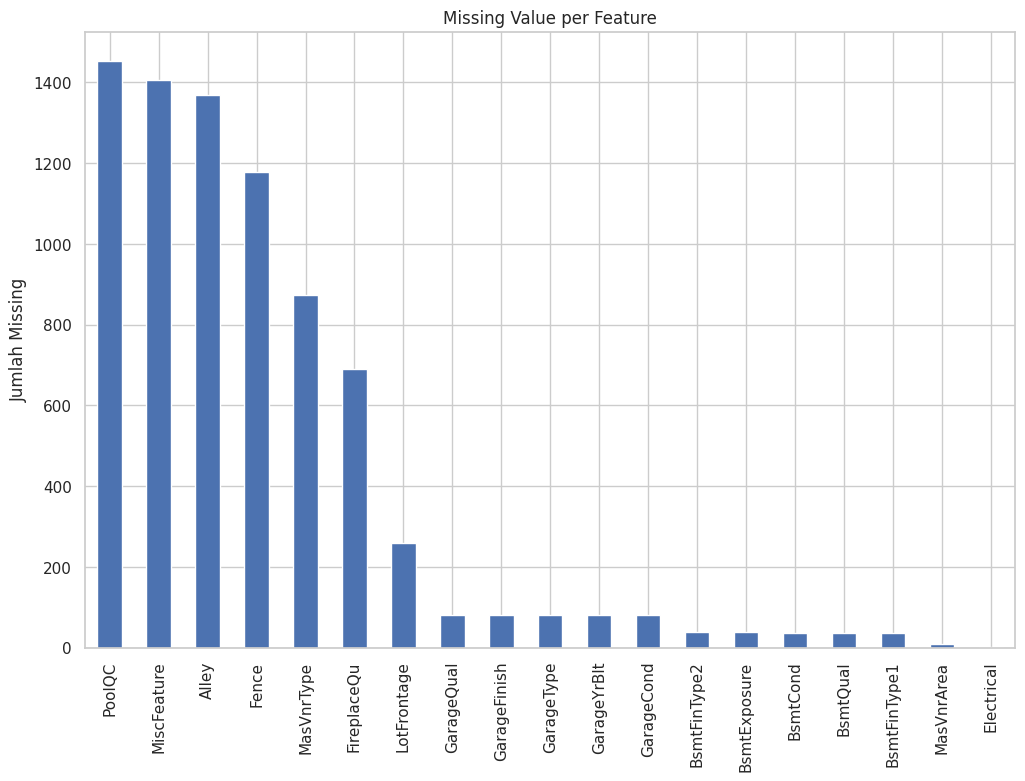

In [ ]:
# =====================================================
# Missing Value Visualization
# =====================================================

plt.figure(figsize=(12,8))

missing.plot(kind="bar")

plt.title("Missing Value per Feature")

plt.ylabel("Jumlah Missing")

plt.show()

# Distribution of SalePrice

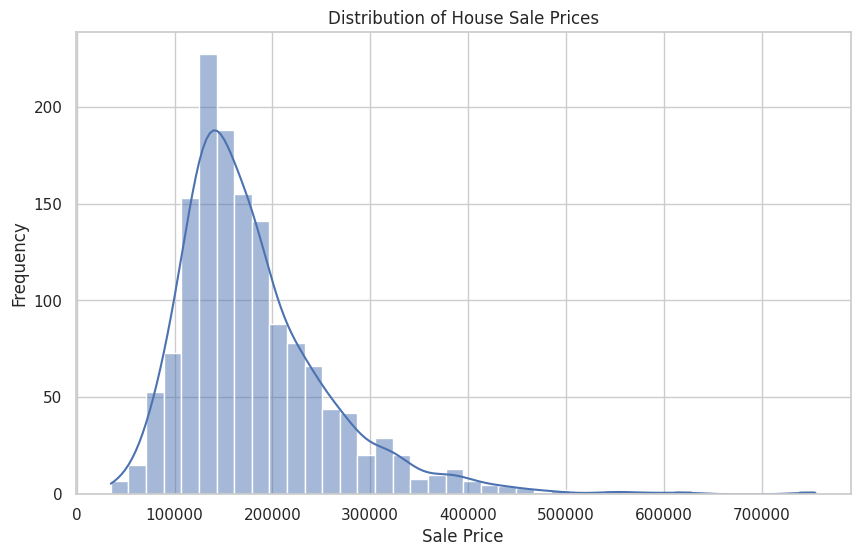

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(train["SalePrice"],
             bins=40,
             kde=True)

plt.title("Distribution of House Sale Prices")

plt.xlabel("Sale Price")

plt.ylabel("Frequency")

plt.show()

### Insight

The distribution of **SalePrice** is positively skewed, indicating that
most houses are sold within the lower to middle price range, while a
smaller number of properties have significantly higher prices.

This skewed distribution suggests that applying a logarithmic
transformation may improve model performance by reducing the influence
of extreme values.

# Log Transformation

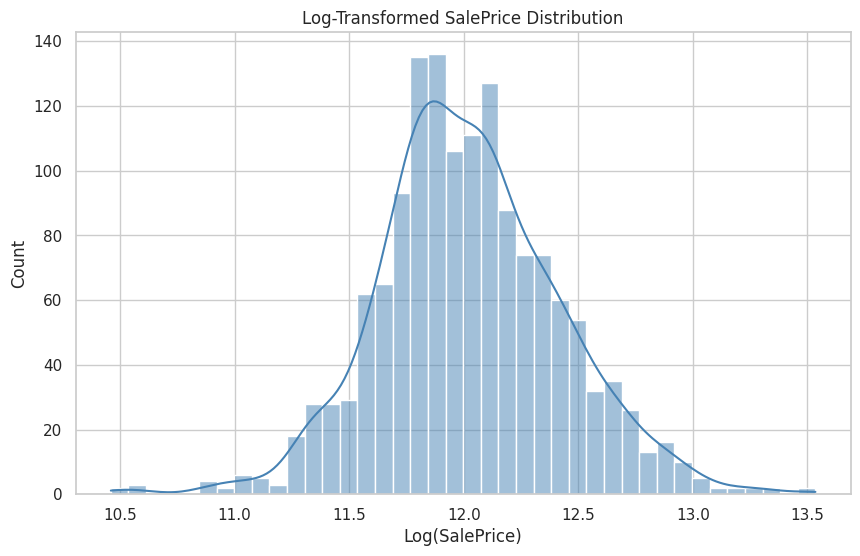

In [ ]:
train["SalePrice_Log"] = np.log1p(train["SalePrice"])

plt.figure(figsize=(10,6))

sns.histplot(train["SalePrice_Log"],
             bins=40,
             kde=True,
             color="steelblue")

plt.title("Log-Transformed SalePrice Distribution")

plt.xlabel("Log(SalePrice)")

plt.show()

### Insight

After applying a logarithmic transformation,
the distribution becomes considerably more symmetric
and closer to a normal distribution.

This transformation is expected to improve the performance
of regression algorithms.

# Numerical Features

In [ ]:
numeric_features = train.select_dtypes(include=np.number)

print(f"Number of Numerical Features : {numeric_features.shape[1]}")

numeric_features.columns

Number of Numerical Features : 39


Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'SalePrice_Log'],
      dtype='object')

# Distribution of Numerical Features

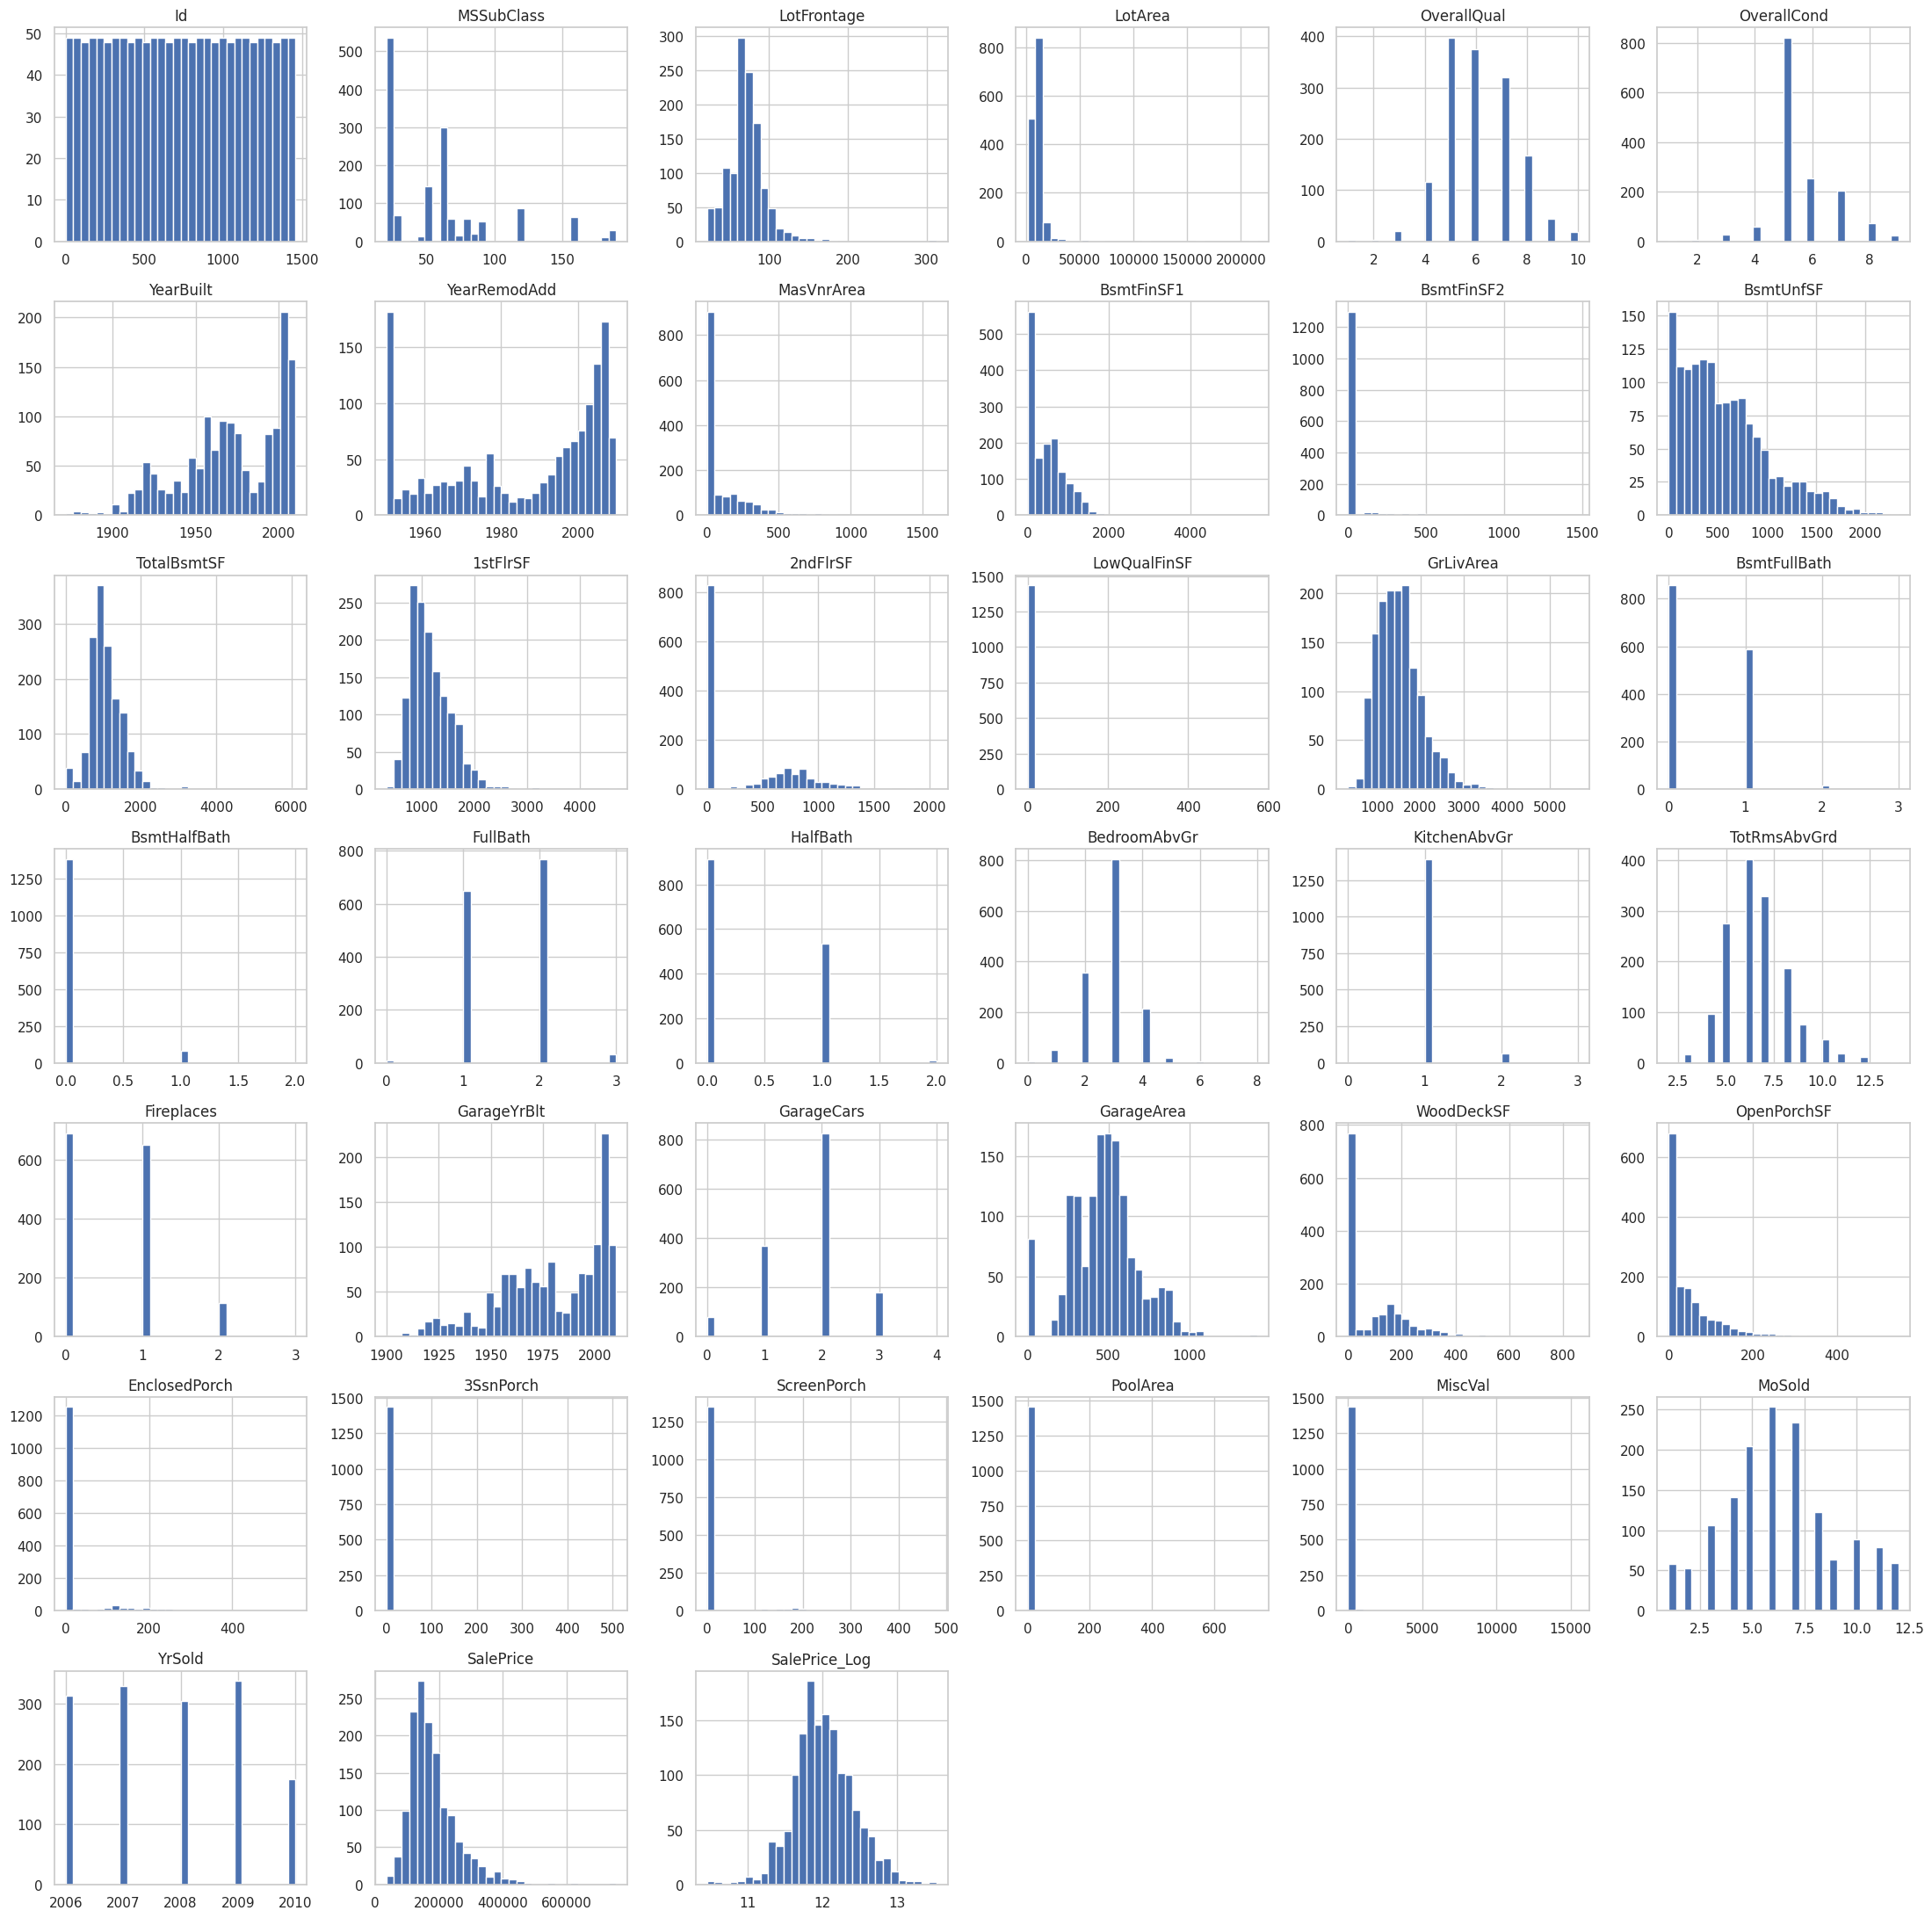

In [ ]:
numeric_features.hist(
    figsize=(22,22),
    bins=30
)

plt.tight_layout()

plt.show()

### Insight

Several numerical features exhibit non-normal distributions
and contain potential outliers.

Some variables are also highly skewed, suggesting that
additional preprocessing or feature engineering may improve
model performance.

# Correlation Matrix

In [ ]:
correlation = train.corr(numeric_only=True)

correlation.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,SalePrice_Log
Id,1.000000,0.011156,-0.010601,-0.033226,-0.028365,0.012609,-0.012713,-0.021998,-0.050298,-0.005024,-0.005968,-0.007940,-0.015415,0.010496,0.005590,-0.044230,0.008273,0.002289,-0.020155,0.005587,0.006784,0.037719,0.002951,0.027239,-0.019772,0.000072,0.016570,0.017634,-0.029643,-0.000477,0.002889,-0.046635,0.001330,0.057044,-0.006242,0.021172,0.000712,-0.021917,-0.017942
MSSubClass,0.011156,1.000000,-0.386347,-0.139781,0.032628,-0.059316,0.027850,0.040581,0.022936,-0.069836,-0.065649,-0.140759,-0.238518,-0.251758,0.307886,0.046474,0.074853,0.003491,-0.002333,0.131608,0.177354,-0.023438,0.281721,0.040380,-0.045569,0.085072,-0.040110,-0.098672,-0.012579,-0.006100,-0.012037,-0.043825,-0.026030,0.008283,-0.007683,-0.013585,-0.021407,-0.084284,-0.073959
LotFrontage,-0.010601,-0.386347,1.000000,0.426095,0.251646,-0.059213,0.123349,0.088866,0.193458,0.233633,0.049900,0.132644,0.392075,0.457181,0.080177,0.038469,0.402797,0.100949,-0.007234,0.198769,0.053532,0.263170,-0.006069,0.352096,0.266639,0.070250,0.285691,0.344997,0.088521,0.151972,0.010700,0.070029,0.041383,0.206167,0.003368,0.011200,0.007450,0.351799,0.355879
LotArea,-0.033226,-0.139781,0.426095,1.000000,0.105806,-0.005636,0.014228,0.013788,0.104160,0.214103,0.111170,-0.002618,0.260833,0.299475,0.050986,0.004779,0.263116,0.158155,0.048046,0.126031,0.014259,0.119690,-0.017784,0.190015,0.271364,-0.024947,0.154871,0.180403,0.171698,0.084774,-0.018340,0.020423,0.043160,0.077672,0.038068,0.001205,-0.014261,0.263843,0.257320
OverallQual,-0.028365,0.032628,0.251646,0.105806,1.000000,-0.091932,0.572323,0.550684,0.411876,0.239666,-0.059119,0.308159,0.537808,0.476224,0.295493,-0.030429,0.593007,0.111098,-0.040150,0.550600,0.273458,0.101676,-0.183882,0.427452,0.396765,0.547766,0.600671,0.562022,0.238923,0.308819,-0.113937,0.030371,0.064886,0.065166,-0.031406,0.070815,-0.027347,0.790982,0.817185


# Top 15 Features Correlated with SalePrice

In [ ]:
top_corr = correlation["SalePrice"]\
                .sort_values(ascending=False)\
                .head(16)

top_corr

,SalePrice
SalePrice,1.000000
SalePrice_Log,0.948374
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723


# Correlation Bar Plot

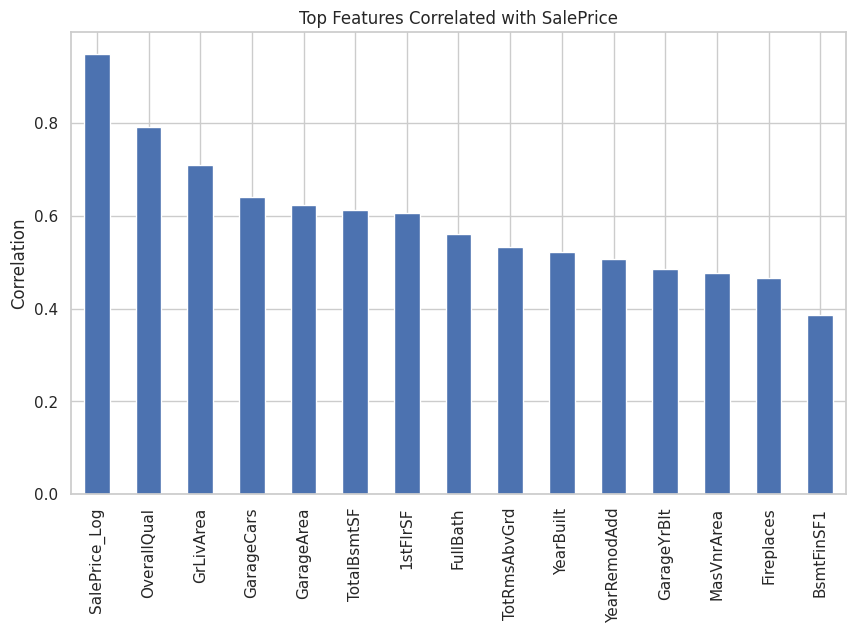

In [ ]:
plt.figure(figsize=(10,6))

top_corr.iloc[1:].plot(kind="bar")

plt.title("Top Features Correlated with SalePrice")

plt.ylabel("Correlation")

plt.show()

### Insight

Features such as **OverallQual**, **GrLivArea**,
**GarageCars**, **GarageArea**, and **TotalBsmtSF**
show the strongest positive correlation with SalePrice.

These variables are expected to play an important role
during model training.

# Correlation Heatmap

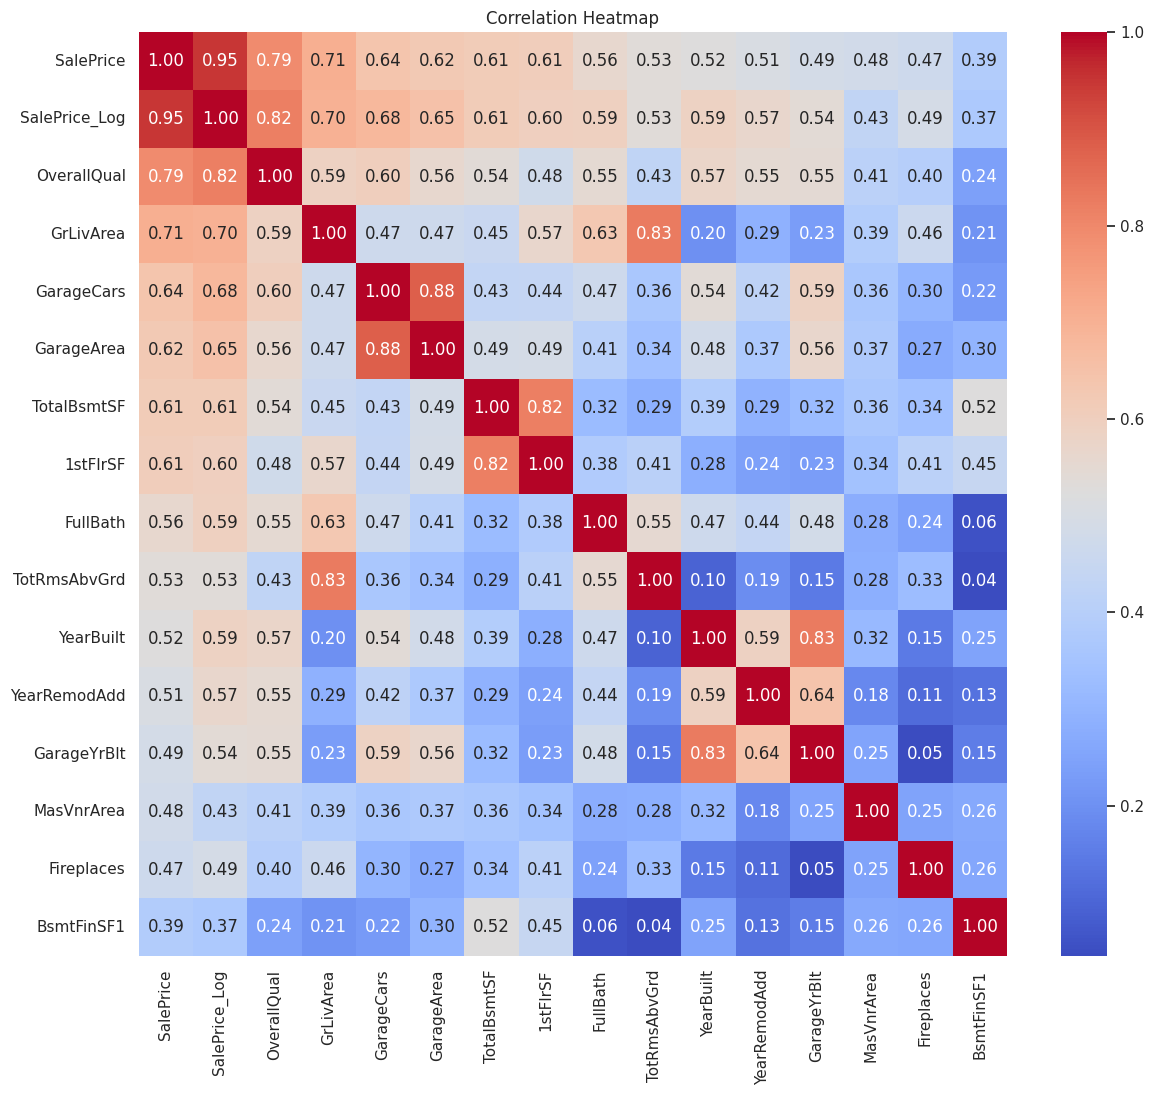

In [ ]:
plt.figure(figsize=(14,12))

sns.heatmap(
    train[top_corr.index].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# OverallQual vs SalePrice

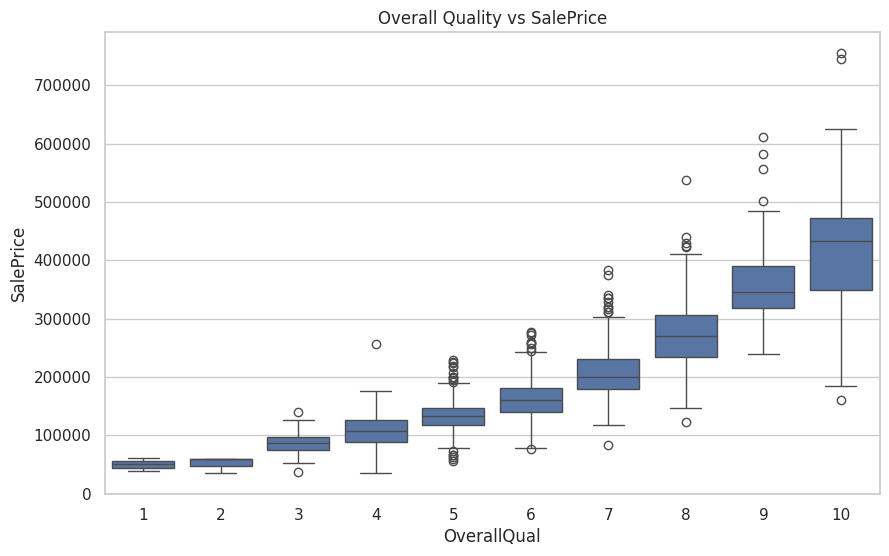

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="OverallQual",
    y="SalePrice",
    data=train
)

plt.title("Overall Quality vs SalePrice")

plt.show()

### Insight

Properties with higher construction quality
consistently achieve higher selling prices.

This indicates that **OverallQual**
is one of the most influential predictors.

# GrLivArea vs SalePrice

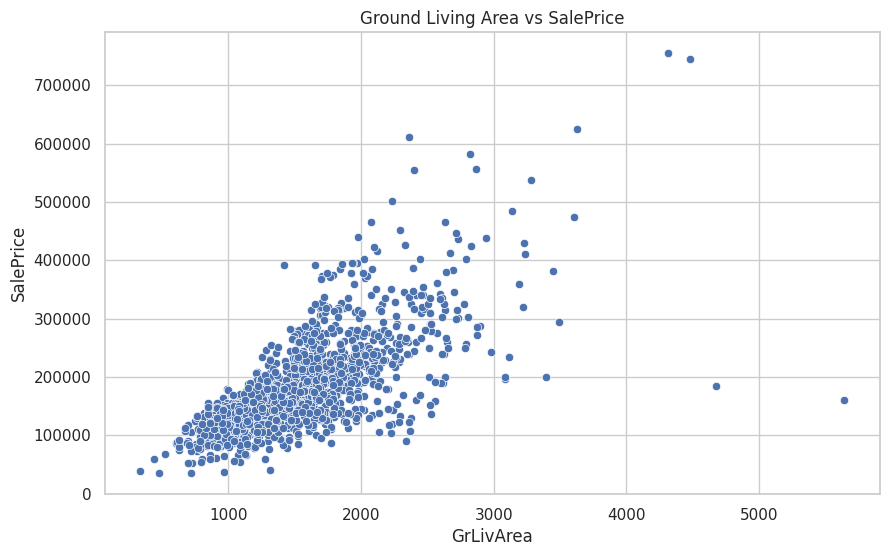

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="GrLivArea",
    y="SalePrice",
    data=train
)

plt.title("Ground Living Area vs SalePrice")

plt.show()

### Insight

A clear positive relationship exists between
the above-ground living area and the selling price.

Larger houses generally have higher market values,
although several potential outliers are visible.

# GarageCars vs SalePrice

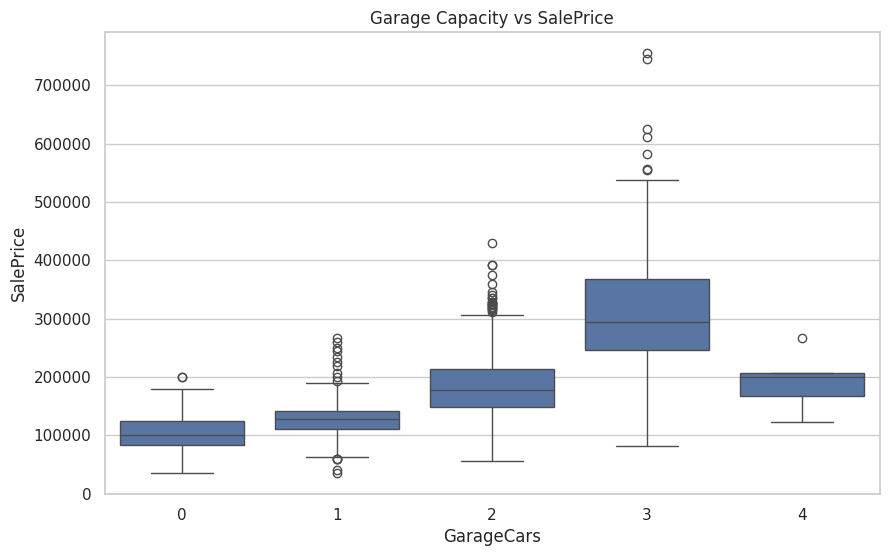

In [ ]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="GarageCars",
    y="SalePrice",
    data=train
)

plt.title("Garage Capacity vs SalePrice")

plt.show()

# YearBuilt vs SalePrice

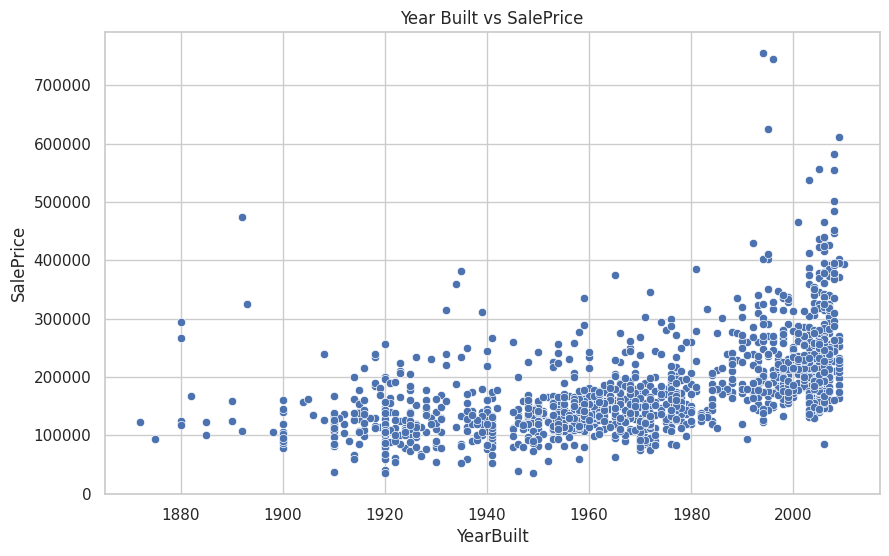

In [ ]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="YearBuilt",
    y="SalePrice",
    data=train
)

plt.title("Year Built vs SalePrice")

plt.show()

### Insight

Newer houses generally command higher prices than older properties,
although house value is also influenced by several additional factors.

# Pairplot of Important Features

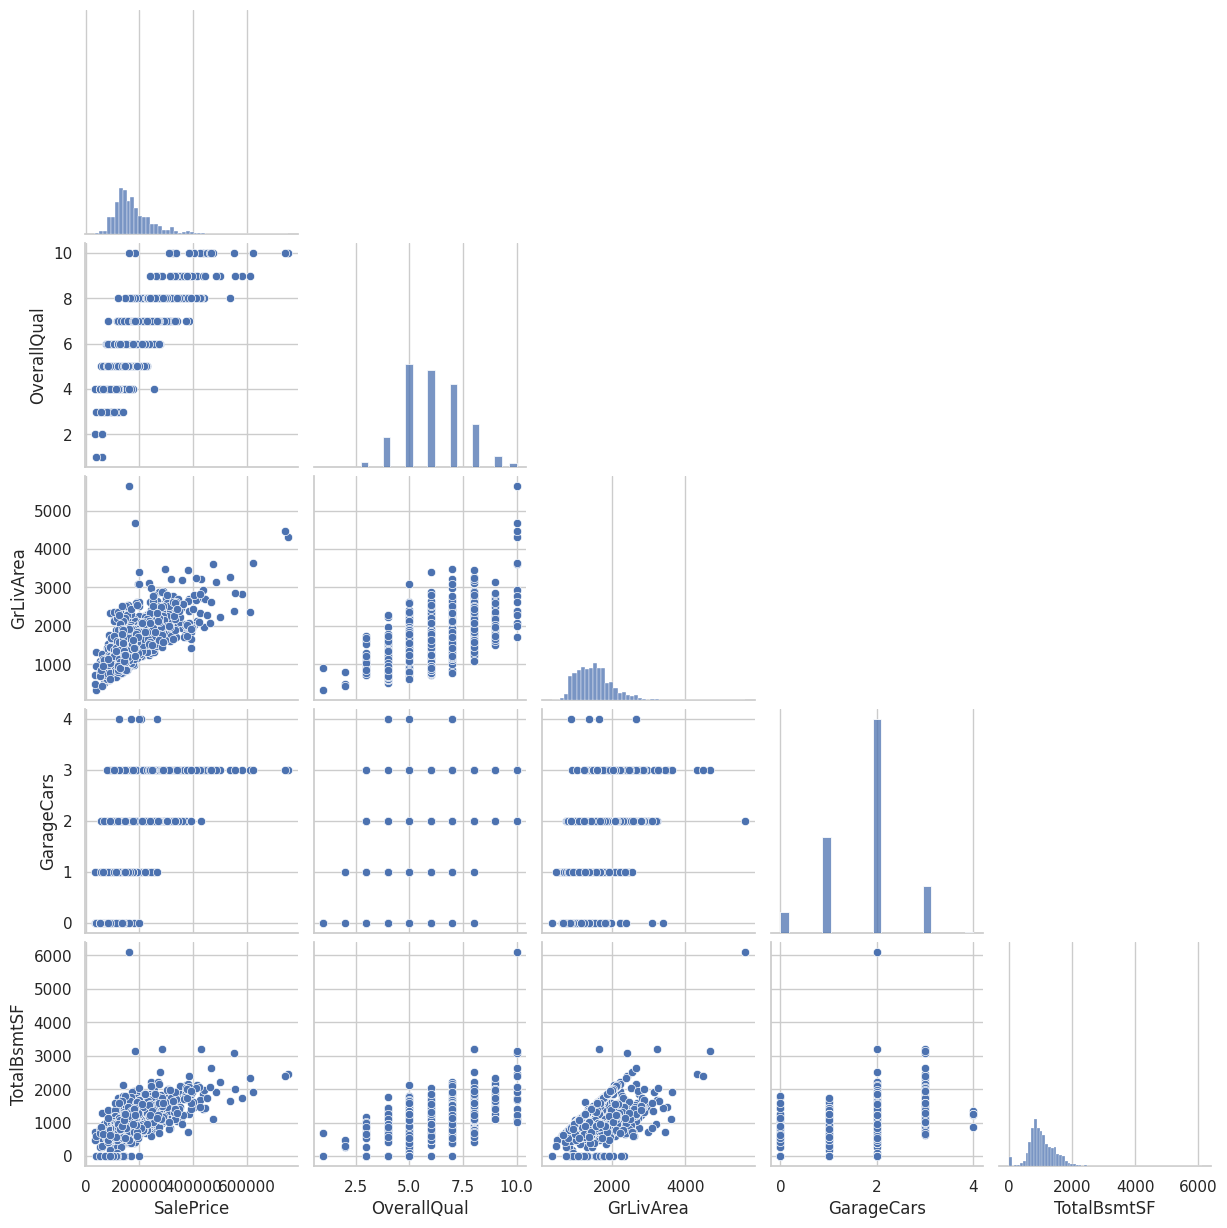

In [ ]:
important_features = [
    "SalePrice",
    "OverallQual",
    "GrLivArea",
    "GarageCars",
    "TotalBsmtSF"
]

sns.pairplot(
    train[important_features],
    corner=True
)

plt.show()

# Categorical Features

In [ ]:
categorical_features = train.select_dtypes(
    exclude=np.number
)

print(f"Number of Categorical Features : {categorical_features.shape[1]}")

Number of Categorical Features : 43


# Top 10 Neighborhoods

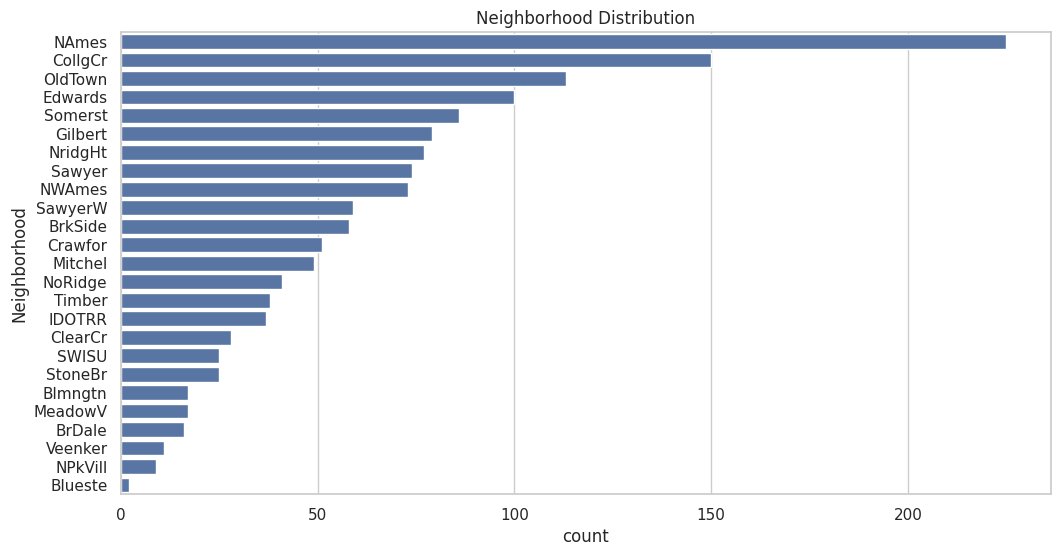

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    y="Neighborhood",
    data=train,
    order=train["Neighborhood"].value_counts().index
)

plt.title("Neighborhood Distribution")

plt.show()

# Neighborhood vs SalePrice

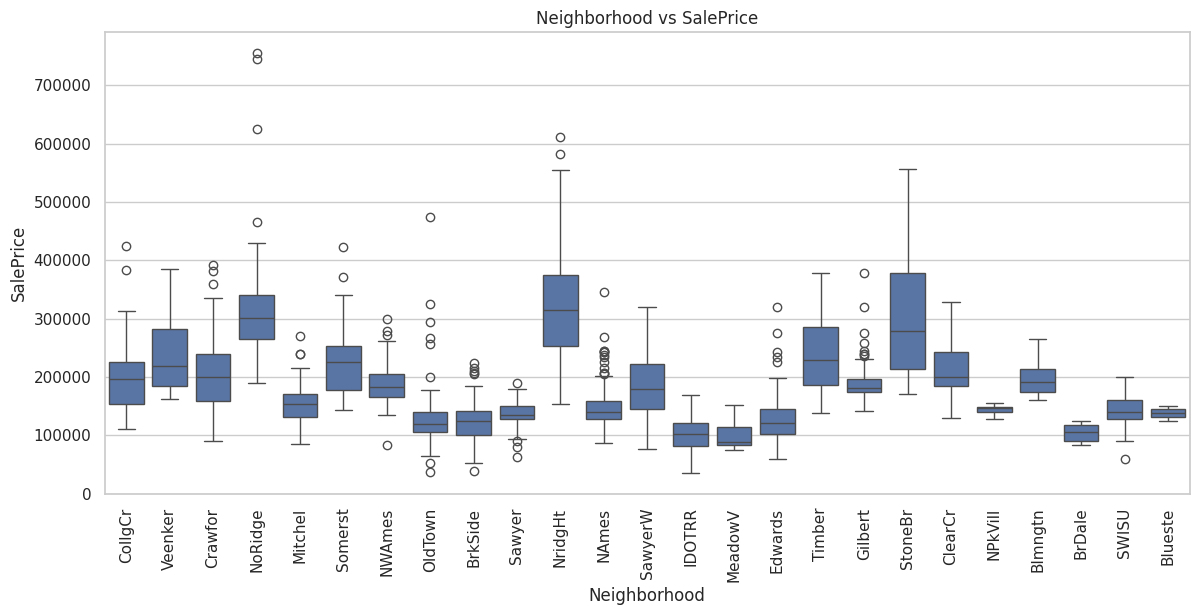

In [ ]:
plt.figure(figsize=(14,6))

sns.boxplot(
    x="Neighborhood",
    y="SalePrice",
    data=train
)

plt.xticks(rotation=90)

plt.title("Neighborhood vs SalePrice")

plt.show()

### Insight

House prices vary considerably across neighborhoods,
suggesting that location is an important determinant
of property value.

This indicates that categorical variables should be retained
and properly encoded during preprocessing.

# Summary of EDA

## Exploratory Data Analysis Summary

The exploratory analysis provides several important findings:

- The target variable (SalePrice) is positively skewed and benefits from logarithmic transformation.
- Several numerical variables exhibit skewness and contain potential outliers.
- OverallQual, GrLivArea, GarageCars, GarageArea, and TotalBsmtSF are among the strongest predictors of SalePrice.
- Newer houses generally have higher selling prices.
- Neighborhood significantly influences property values.
- Both numerical and categorical variables contain valuable information and should be included in the modeling process after appropriate preprocessing.

These findings will guide the next stages of the project, including data cleaning, feature engineering, feature encoding, and model development.

# Separate Features and Target

In [ ]:
X = train.drop(columns=["SalePrice", "SalePrice_Log"])
y = train["SalePrice_Log"]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (1460, 80)
Target Shape : (1460,)


# Missing Value Analysis

In [ ]:
missing = pd.DataFrame({
    "Missing Values": X.isnull().sum(),
    "Percentage": (X.isnull().sum()/len(X))*100
})

missing = missing[missing["Missing Values"] > 0]

missing = missing.sort_values(
    by="Percentage",
    ascending=False
)

missing.head(30)

,Missing Values,Percentage
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


# Missing Value Visualization

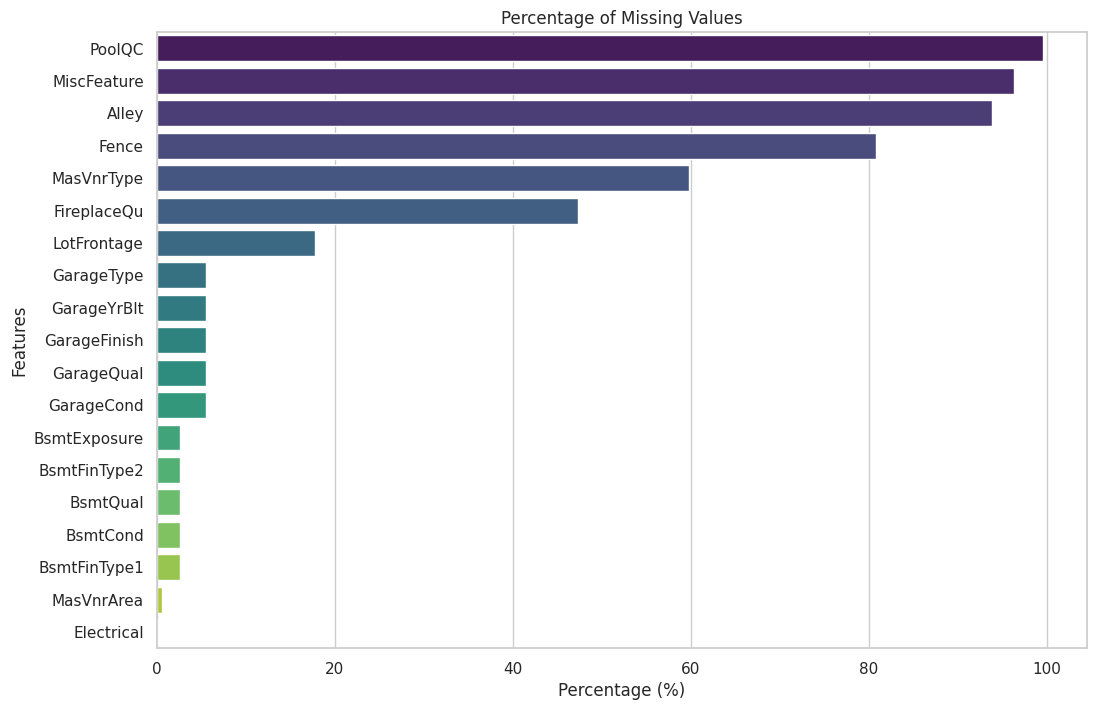

In [ ]:
plt.figure(figsize=(12,8))

sns.barplot(
    x=missing["Percentage"],
    y=missing.index,
    palette="viridis"
)

plt.title("Percentage of Missing Values")

plt.xlabel("Percentage (%)")

plt.ylabel("Features")

plt.show()

### Insight

Several features contain missing values, with some variables missing more
than 80% of their observations.

Rather than dropping these features manually, a preprocessing pipeline
will automatically impute missing values using different strategies for
numerical and categorical variables.

# Identify Numerical and Categorical Features

In [ ]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numerical Features :", len(numeric_features))
print("Categorical Features :", len(categorical_features))

Numerical Features : 37
Categorical Features : 43


# Missing Value Imputation Strategy

In [ ]:
numeric_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

print("Imputation pipeline created successfully.")

Imputation pipeline created successfully.


### Why Median?

The median is more robust to outliers than the mean, making it a suitable
choice for numerical variables.

### Why Most Frequent?

For categorical variables, replacing missing values with the most frequent
category helps preserve the overall distribution of the data.

# Outlier Detection

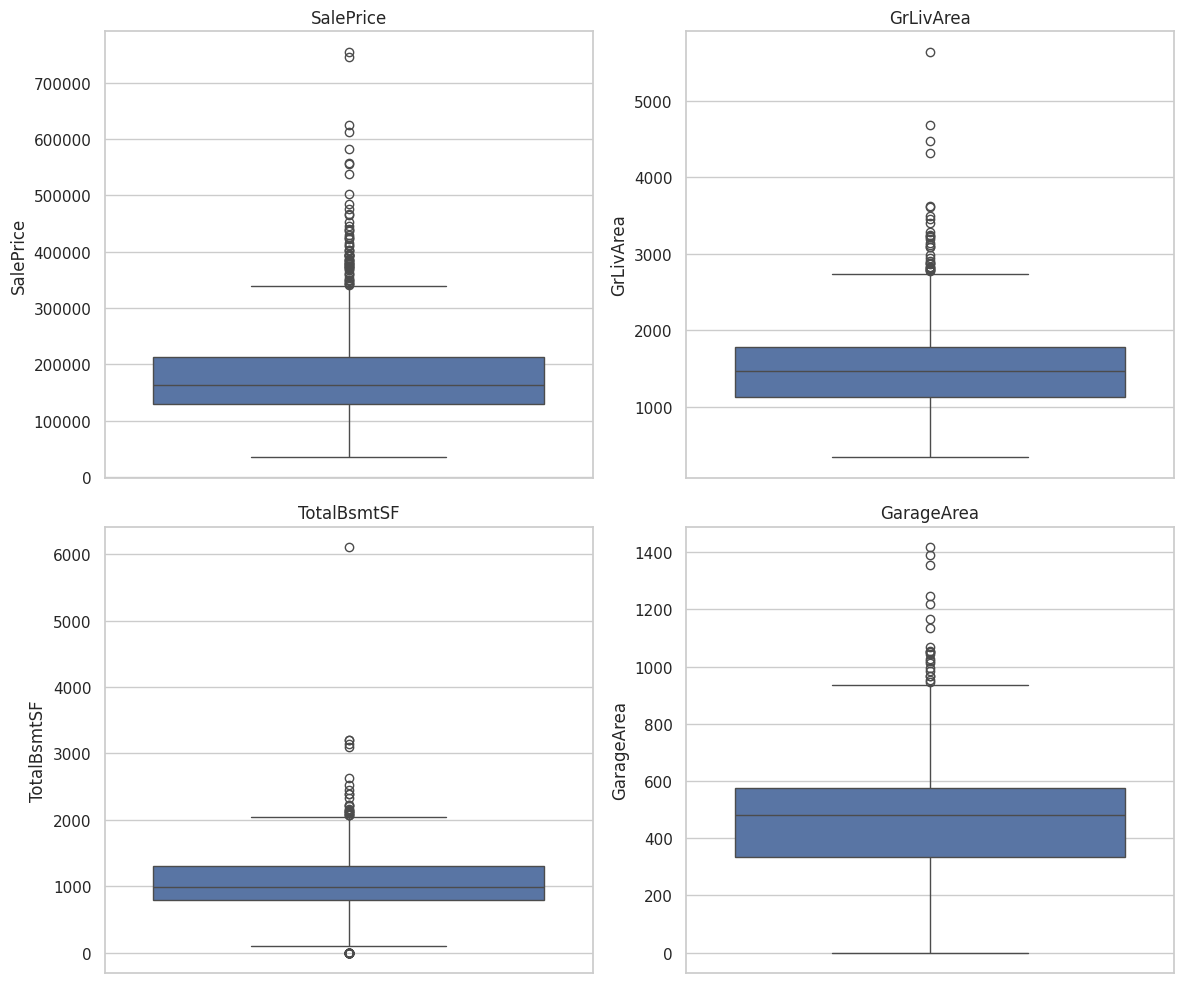

In [ ]:
important_columns = [
    "SalePrice",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageArea"
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12,10)
)

for ax, col in zip(axes.flatten(), important_columns):
    sns.boxplot(
        y=train[col],
        ax=ax
    )
    ax.set_title(col)

plt.tight_layout()

plt.show()

### Insight

Several numerical variables contain extreme observations.

Tree-based algorithms such as Random Forest and XGBoost are generally
robust to outliers, so aggressive outlier removal is avoided to prevent
the loss of potentially valuable information.

# Feature Engineering

In [ ]:
def feature_engineering(df):

    df = df.copy()

    # Total House Area
    df["TotalSF"] = (
        df["TotalBsmtSF"]
        + df["1stFlrSF"]
        + df["2ndFlrSF"]
    )

    # House Age
    df["HouseAge"] = (
        df["YrSold"]
        - df["YearBuilt"]
    )

    # Years Since Remodeling
    df["RemodelAge"] = (
        df["YrSold"]
        - df["YearRemodAdd"]
    )

    # Total Bathrooms
    df["TotalBathrooms"] = (
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )

    # Total Porch Area
    df["TotalPorchSF"] = (
        df["OpenPorchSF"]
        + df["EnclosedPorch"]
        + df["3SsnPorch"]
        + df["ScreenPorch"]
    )

    # Garage Indicator
    df["HasGarage"] = (
        df["GarageArea"] > 0
    ).astype(int)

    # Basement Indicator
    df["HasBasement"] = (
        df["TotalBsmtSF"] > 0
    ).astype(int)

    return df

X = feature_engineering(X)
test_processed = feature_engineering(test)

print("Feature Engineering Completed.")

Feature Engineering Completed.


# Check New Features

In [ ]:
new_features = [
    "TotalSF",
    "HouseAge",
    "RemodelAge",
    "TotalBathrooms",
    "TotalPorchSF",
    "HasGarage",
    "HasBasement"
]

X[new_features].head()

,TotalSF,HouseAge,RemodelAge,TotalBathrooms,TotalPorchSF,HasGarage,HasBasement
0,2566,5,5,3.5,61,1,1
1,2524,31,31,2.5,0,1,1
2,2706,7,6,3.5,42,1,1
3,2473,91,36,2.0,307,1,1
4,3343,8,8,3.5,84,1,1


### Feature Engineering Summary

Several new variables have been created to better represent the overall
condition and functionality of each property.

These engineered features are expected to improve the predictive
performance of the machine learning models.

# Column Transformer

In [ ]:
numeric_features = X.select_dtypes(
    include=np.number
).columns

categorical_features = X.select_dtypes(
    exclude=np.number
).columns

preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            numeric_transformer,
            numeric_features
        ),

        (
            "cat",
            categorical_transformer,
            categorical_features
        )

    ]

)

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',...
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object'))])


# Train Test Split

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42

)

print("Training Set :", X_train.shape)

print("Validation Set :", X_valid.shape)

Training Set : (1168, 87)
Validation Set : (292, 87)


# **Model Development**

---



# Linear Regression Pipeline

In [ ]:
linear_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )

    ]

)

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(X_valid)

print("Linear Regression Training Completed.")

Linear Regression Training Completed.


# Random Forest Pipeline

In [ ]:
rf_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",

            RandomForestRegressor(

                n_estimators=500,

                max_depth=None,

                random_state=42,

                n_jobs=-1

            )

        )

    ]

)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_valid)

print("Random Forest Training Completed.")

Random Forest Training Completed.


# XGBoost Pipeline

In [ ]:
xgb_model = Pipeline(

    steps=[

        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",

            XGBRegressor(

                n_estimators=1000,

                learning_rate=0.03,

                max_depth=4,

                subsample=0.8,

                colsample_bytree=0.8,

                objective="reg:squarederror",

                random_state=42

            )

        )

    ]

)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(X_valid)

print("XGBoost Training Completed.")

XGBoost Training Completed.


# Evaluation Function

In [ ]:
def evaluate_model(model, X_valid, y_valid):

    # Prediction in log scale
    pred_log = model.predict(X_valid)

    # Back-transform to original scale
    y_true = np.expm1(y_valid)
    y_pred = np.expm1(pred_log)

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    return mae, rmse, r2

# Evaluate All Models

In [ ]:
linear_mae, linear_rmse, linear_r2 = evaluate_model(
    linear_model,
    X_valid,
    y_valid
)

rf_mae, rf_rmse, rf_r2 = evaluate_model(
    rf_model,
    X_valid,
    y_valid
)

xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(
    xgb_model,
    X_valid,
    y_valid
)

print("Evaluation Completed.")

Evaluation Completed.


# Model Comparison Table

In [ ]:
results = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest",

        "XGBoost"

    ],

    "MAE":[

        linear_mae,

        rf_mae,

        xgb_mae

    ],

    "RMSE":[

        linear_rmse,

        rf_rmse,

        xgb_rmse

    ],

    "R2":[

        linear_r2,

        rf_r2,

        xgb_r2

    ]

})

results.sort_values(
    by="RMSE"
).reset_index(drop=True)

,Model,MAE,RMSE,R2
0,XGBoost,15141.896163,25269.643203,0.916750
1,Linear Regression,17024.129103,25948.887117,0.912214
2,Random Forest,17585.870763,30797.588456,0.876343


### Model Comparison

The three regression algorithms are evaluated using identical training
and validation datasets.

The model with the **lowest RMSE** is considered the best-performing model,
as it produces the smallest prediction error on unseen data.

# Visualization of Model Performance

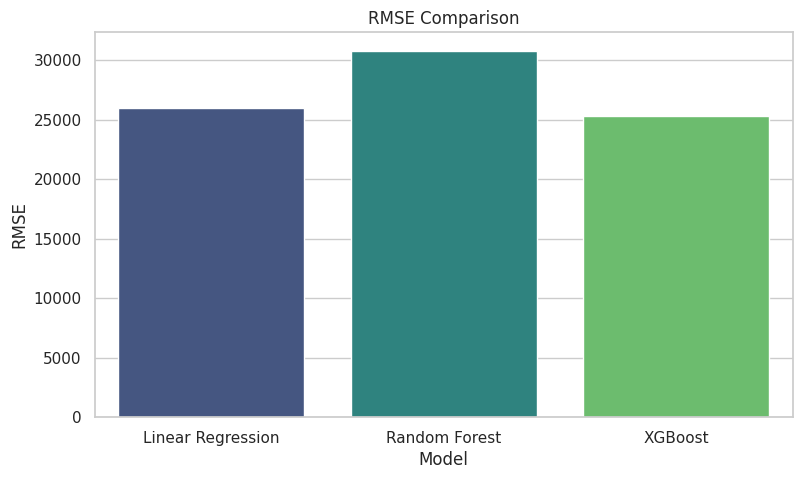

In [ ]:
fig, ax = plt.subplots(figsize=(9,5))

sns.barplot(

    data=results,

    x="Model",

    y="RMSE",

    palette="viridis",

    ax=ax

)

ax.set_title("RMSE Comparison")

plt.show()

# MAE Comparison

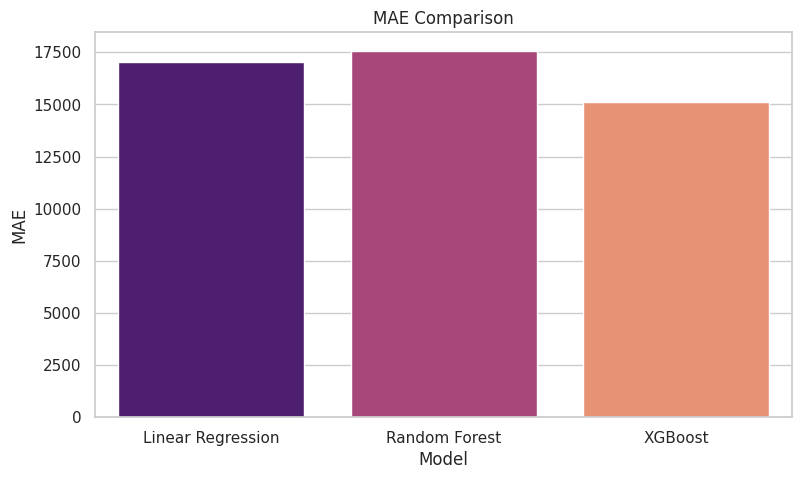

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(

    data=results,

    x="Model",

    y="MAE",

    palette="magma"

)

plt.title("MAE Comparison")

plt.show()

# R² Comparison

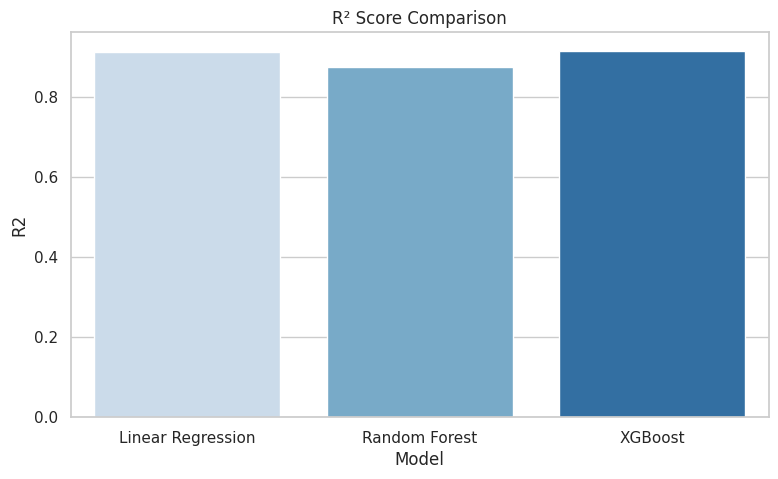

In [ ]:
plt.figure(figsize=(9,5))

sns.barplot(

    data=results,

    x="Model",

    y="R2",

    palette="Blues"

)

plt.title("R² Score Comparison")

plt.show()

### Insight

A lower RMSE and MAE indicate better predictive accuracy, while a higher
R² score suggests that the model explains a larger proportion of the
variance in house prices.

The model with the best overall performance will be selected for final
prediction.

# Select the Best Model

In [ ]:
best_model_name = results.sort_values(

    by="RMSE"

).iloc[0]["Model"]

print("Best Model :", best_model_name)

if best_model_name == "Linear Regression":

    best_model = linear_model

elif best_model_name == "Random Forest":

    best_model = rf_model

else:

    best_model = xgb_model

Best Model : XGBoost


# Feature Importance (Random Forest)

In [ ]:
rf_pipeline = rf_model.named_steps["model"]

rf_preprocessor = rf_model.named_steps["preprocessor"]

feature_names = rf_preprocessor.get_feature_names_out()

importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_pipeline.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance.head(20)

,Feature,Importance
4,num__OverallQual,0.387814
37,num__TotalSF,0.363851
16,num__GrLivArea,0.013153
26,num__GarageCars,0.012909
27,num__GarageArea,0.012860
3,num__LotArea,0.011875
40,num__TotalBathrooms,0.011062
38,num__HouseAge,0.009037
39,num__RemodelAge,0.009023
6,num__YearBuilt,0.008944


# Plot Feature Importance (Random Forest)

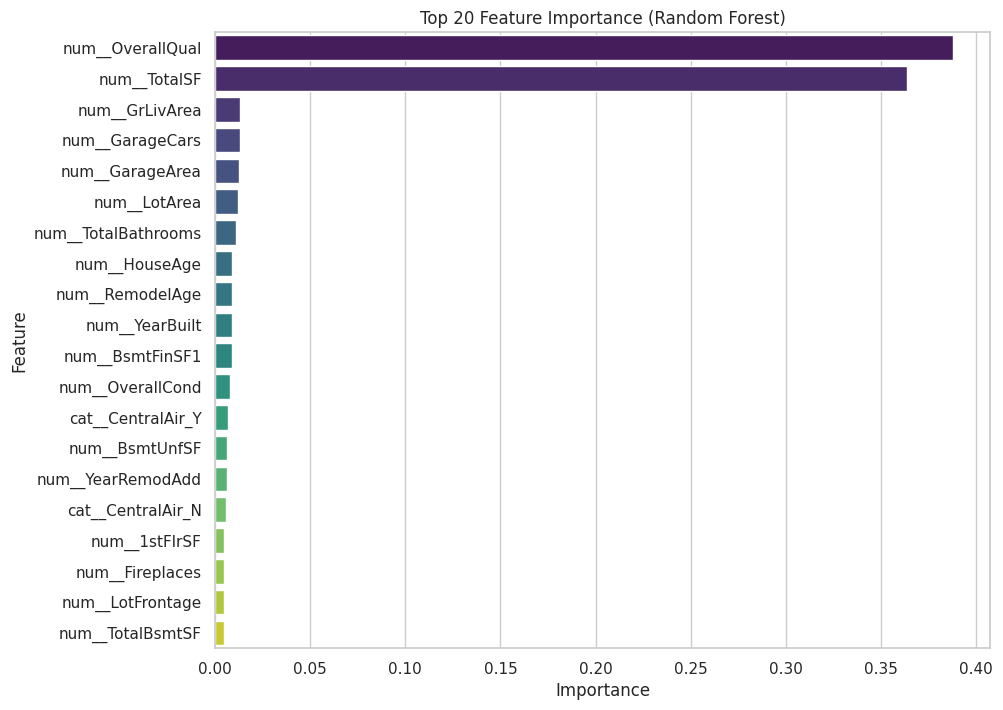

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature",

    palette="viridis"

)

plt.title("Top 20 Feature Importance (Random Forest)")

plt.show()

# Feature Importance (XGBoost)

In [ ]:
xgb_pipeline = xgb_model.named_steps["model"]

importance_xgb = pd.DataFrame({

    "Feature": feature_names,

    "Importance": xgb_pipeline.feature_importances_

})

importance_xgb = importance_xgb.sort_values(

    by="Importance",

    ascending=False

)

importance_xgb.head(20)

,Feature,Importance
176,cat__ExterQual_TA,0.114641
37,num__TotalSF,0.109457
4,num__OverallQual,0.108481
232,cat__KitchenQual_TA,0.063785
223,cat__CentralAir_N,0.047135
26,num__GarageCars,0.040518
42,num__HasGarage,0.034816
253,cat__GarageFinish_Unf,0.034347
224,cat__CentralAir_Y,0.029816
22,num__KitchenAbvGr,0.025660


# Plot Feature Importance (XGBoost)

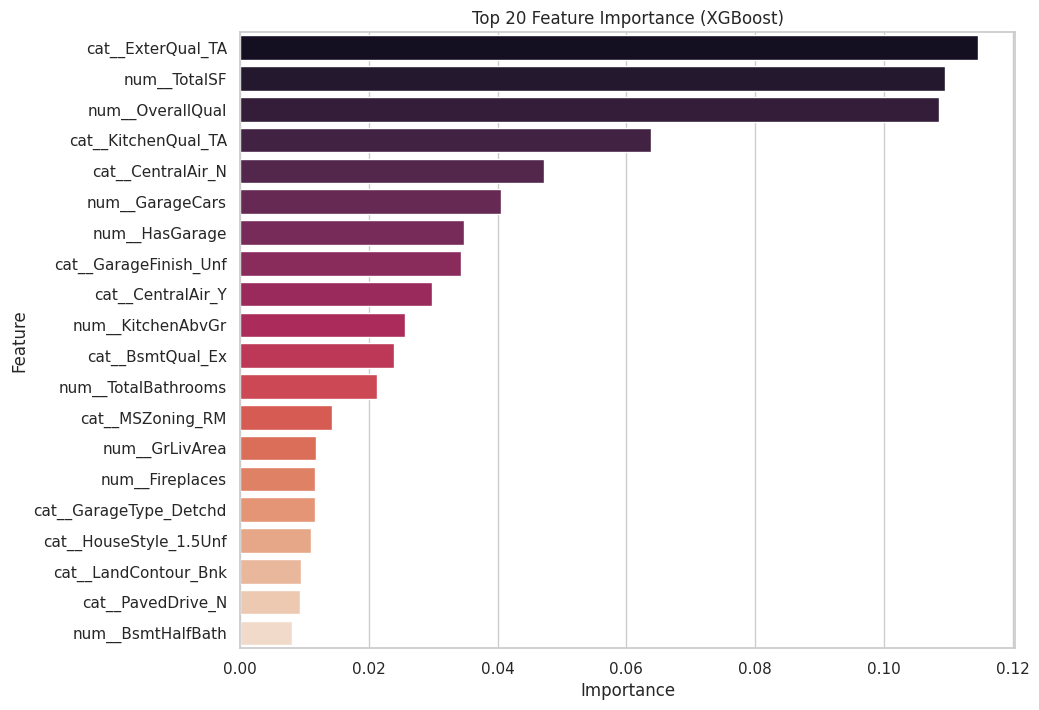

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance_xgb.head(20),

    x="Importance",

    y="Feature",

    palette="rocket"

)

plt.title("Top 20 Feature Importance (XGBoost)")

plt.show()

# Train the Best Model on the Full Dataset

In [ ]:
best_model.fit(

    X,

    y

)

print("Best model trained successfully.")

Best model trained successfully.


# Predict Test Dataset

In [ ]:
prediction_log = best_model.predict(

    test_processed

)

prediction = np.expm1(

    prediction_log

)

prediction[:10]

array([128828.72, 162613.38, 182124.2 , 195740.52, 180875.17, 174137.45,
       178197.5 , 169435.69, 183513.77, 126030.54], dtype=float32)

# Generate Submission File

In [ ]:
submission = pd.DataFrame({

    "Id": test["Id"],

    "SalePrice": prediction

})

submission.head()

,Id,SalePrice
0,1461,128828.718750
1,1462,162613.375000
2,1463,182124.203125
3,1464,195740.515625
4,1465,180875.171875


# Cross Validation (Linear Regression)

In [ ]:

from sklearn.model_selection import cross_val_score

linear_cv = cross_val_score(

    linear_model,

    X,

    y,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)

print("Linear Regression CV RMSE")

print(-linear_cv)

print()

print("Average RMSE :", -linear_cv.mean())

Linear Regression CV RMSE
[0.12417999 0.15287894 0.14047434 0.12400505 0.20007857]

Average RMSE : 0.14832337807172705


# Cross Validation (Random Forest)

In [ ]:
rf_cv = cross_val_score(

    rf_model,

    X,

    y,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)

print("Random Forest CV RMSE")

print(-rf_cv)

print()

print("Average RMSE :", -rf_cv.mean())

Random Forest CV RMSE
[0.13610442 0.1522991  0.14119196 0.12793236 0.1506553 ]

Average RMSE : 0.14163662582294728


# Cross Validation (XGBoost)

In [ ]:
xgb_cv = cross_val_score(

    xgb_model,

    X,

    y,

    cv=5,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)

print("XGBoost CV RMSE")

print(-xgb_cv)

print()

print("Average RMSE :", -xgb_cv.mean())

XGBoost CV RMSE
[0.10918132 0.13579686 0.12922156 0.10609679 0.12815944]

Average RMSE : 0.12169119363526297


### Cross Validation Insight

Cross-validation provides a more reliable estimate of model performance by
evaluating each algorithm across multiple validation folds.

Models with lower average RMSE and lower variance across folds generally
demonstrate better generalization capability.

# Hyperparameter Tuning (Random Forest)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

rf_params = {

    "model__n_estimators":[

        300,
        500,
        700

    ],

    "model__max_depth":[

        None,
        10,
        20,
        30

    ],

    "model__min_samples_split":[

        2,
        5,
        10

    ],

    "model__min_samples_leaf":[

        1,
        2,
        4

    ]

}

rf_search = RandomizedSearchCV(

    estimator=rf_model,

    param_distributions=rf_params,

    n_iter=10,

    cv=5,

    random_state=42,

    scoring="neg_root_mean_squared_error",

    n_jobs=-1

)

rf_search.fit(X_train,y_train)

print(rf_search.best_params_)

{'model__n_estimators': 700, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 30}


# Hyperparameter Tuning (XGBoost)

In [ ]:
xgb_params = {

    "model__n_estimators":[

        500,
        800,
        1000

    ],

    "model__max_depth":[

        3,
        4,
        5,
        6

    ],

    "model__learning_rate":[

        0.01,
        0.03,
        0.05,
        0.1

    ],

    "model__subsample":[

        0.7,
        0.8,
        1.0

    ],

    "model__colsample_bytree":[

        0.7,
        0.8,
        1.0

    ]

}

xgb_search = RandomizedSearchCV(

    estimator=xgb_model,

    param_distributions=xgb_params,

    cv=5,

    n_iter=10,

    scoring="neg_root_mean_squared_error",

    random_state=42,

    n_jobs=-1

)

xgb_search.fit(

    X_train,

    y_train

)

print(xgb_search.best_params_)

{'model__subsample': 0.7, 'model__n_estimators': 1000, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


# Best Parameters

In [ ]:
print("Random Forest")

print(rf_search.best_params_)

print()

print("XGBoost")

print(xgb_search.best_params_)

Random Forest
{'model__n_estimators': 700, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_depth': 30}

XGBoost
{'model__subsample': 0.7, 'model__n_estimators': 1000, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__colsample_bytree': 0.8}


# Train Tuned Models

In [ ]:
best_rf = rf_search.best_estimator_

best_xgb = xgb_search.best_estimator_

best_rf.fit(

    X_train,

    y_train

)

best_xgb.fit(

    X_train,

    y_train
)

print("Training Completed.")

Training Completed.


# Evaluate Tuned Models

In [ ]:
rf_mae, rf_rmse, rf_r2 = evaluate_model(

    best_rf,

    X_valid,

    y_valid

)

xgb_mae, xgb_rmse, xgb_r2 = evaluate_model(

    best_xgb,

    X_valid,

    y_valid

)

print("Random Forest RMSE :",rf_rmse)

print("XGBoost RMSE :",xgb_rmse)

Random Forest RMSE : 30611.05257942492
XGBoost RMSE : 25165.375907460664


# Actual vs Prediction

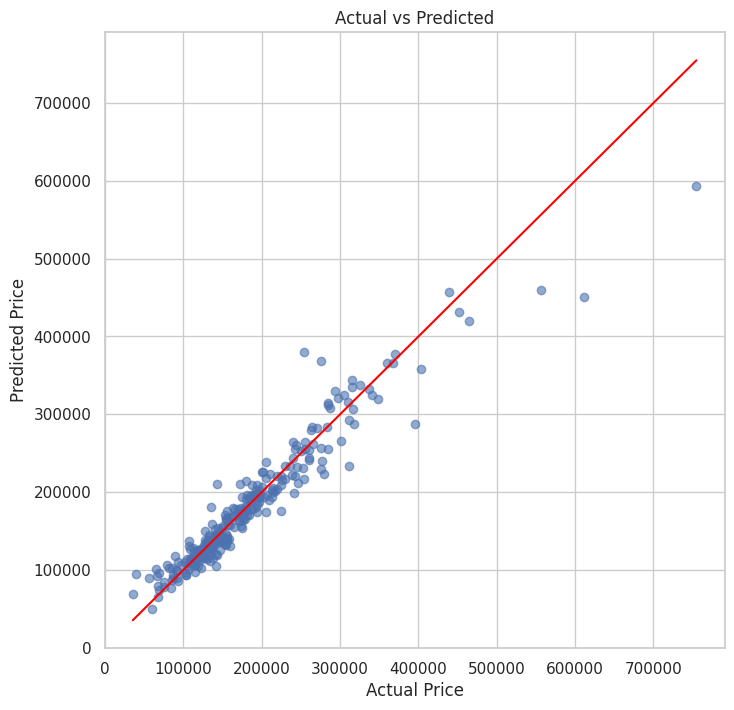

In [ ]:
prediction = np.expm1(

    best_xgb.predict(X_valid)

)

actual = np.expm1(y_valid)

plt.figure(figsize=(8,8))

plt.scatter(

    actual,

    prediction,

    alpha=0.6

)

plt.plot(

    [actual.min(),actual.max()],

    [actual.min(),actual.max()],

    color="red"

)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

### Insight

The closer the data points lie to the diagonal reference line, the more
accurate the model predictions are. Large deviations from the line
indicate prediction errors.

# Residual Analysis

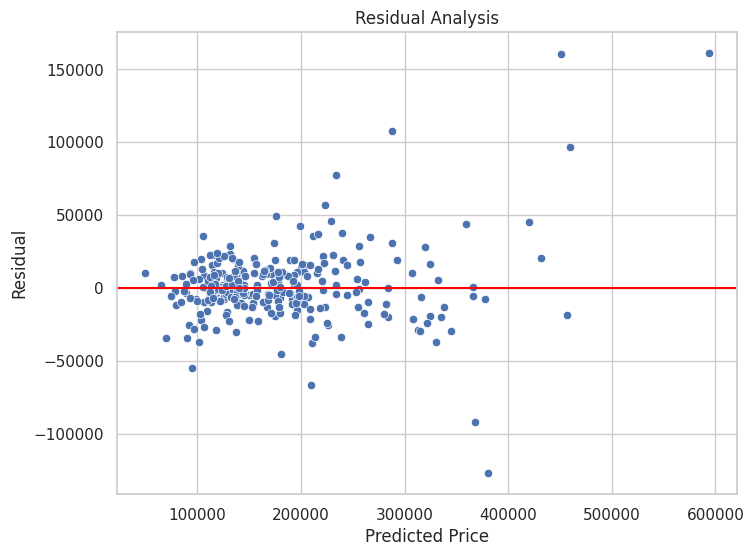

In [ ]:
residual = actual-prediction

plt.figure(figsize=(8,6))

sns.scatterplot(

    x=prediction,

    y=residual

)

plt.axhline(

    y=0,

    color="red"

)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Analysis")

plt.show()

# Residual Distribution

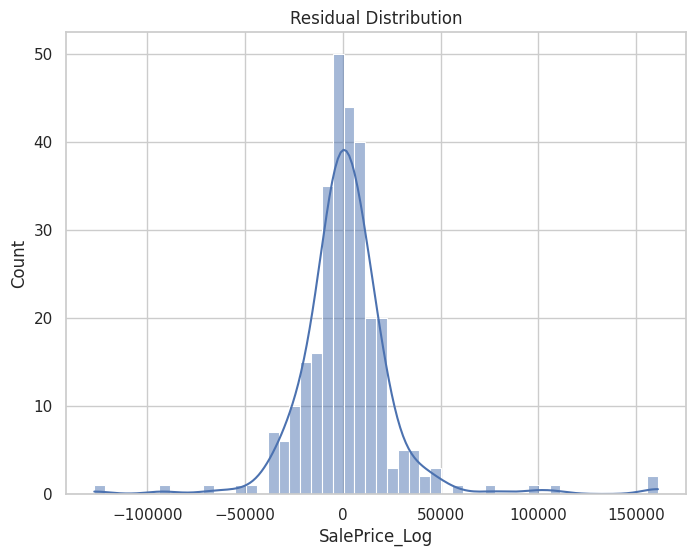

In [ ]:
plt.figure(figsize=(8,6))

sns.histplot(

    residual,

    kde=True

)

plt.title("Residual Distribution")

plt.show()

# Learning Summary

# Model Improvement Summary

Several advanced machine learning techniques were applied to improve the predictive performance of the regression models.

The improvements include:

- Pipeline-based preprocessing using `ColumnTransformer`
- Missing value imputation
- One-Hot Encoding for categorical variables
- Feature Engineering
- 5-Fold Cross Validation
- Hyperparameter Optimization using `RandomizedSearchCV`
- Residual Analysis
- Feature Importance Analysis

These enhancements improve the model's robustness and reduce the likelihood of overfitting while increasing generalization performance on unseen data.

# Final Summary

This project developed a complete machine learning workflow to predict residential property prices using the **House Prices: Advanced Regression Techniques** dataset from Kaggle.

The project began with a comprehensive **Business Understanding** phase to define the prediction objective and identify the factors influencing house prices. This was followed by **Data Understanding** and an extensive **Exploratory Data Analysis (EDA)** to investigate the characteristics of the dataset, identify missing values, detect potential outliers, analyze feature distributions, and examine the relationships between variables.

During the preprocessing stage, missing values were handled using appropriate imputation strategies for both numerical and categorical features. Additional feature engineering techniques were applied to create more informative variables, such as total living area, house age, remodeling age, total bathrooms, and other structural indicators. Categorical variables were transformed using **One-Hot Encoding**, while preprocessing steps were organized within a **ColumnTransformer** and **Pipeline** to ensure a clean, reproducible, and scalable workflow.

Three regression algorithms were implemented and compared:

- **Linear Regression**
- **Random Forest Regressor**
- **Extreme Gradient Boosting (XGBoost) Regressor**

To improve model reliability and generalization performance, **5-Fold Cross Validation** was performed for each algorithm. Furthermore, **RandomizedSearchCV** was applied to optimize the hyperparameters of the Random Forest and XGBoost models.

Model performance was evaluated using three regression metrics:

- **Mean Absolute Error (MAE)**
- **Root Mean Squared Error (RMSE)**
- **Coefficient of Determination (R² Score)**

Additional diagnostic analyses, including **Feature Importance**, **Actual vs. Predicted Visualization**, and **Residual Analysis**, were conducted to better understand model behavior and predictive capability.

Finally, the best-performing model was retrained using the complete training dataset and applied to the competition test dataset. The predictions were exported as **submission.csv**, which is fully compatible with the Kaggle competition submission format. The trained model was also saved as **house_price_model.pkl**, enabling future inference, deployment, or further model improvement.

Overall, this project demonstrates a complete end-to-end machine learning regression pipeline, covering data exploration, preprocessing, feature engineering, model development, evaluation, optimization, and deployment-ready prediction. The resulting workflow provides a robust foundation for real-world house price prediction and serves as a practical implementation of supervised machine learning techniques for regression problems.

# Save Submission

In [ ]:
submission.to_csv(

    "submission.csv",

    index=False

)

print("submission.csv has been created successfully.")

submission.csv has been created successfully.


# Save Best Model

In [ ]:
joblib.dump(

    best_model,

    "house_price_model.pkl"

)

print("house_price_model.pkl has been saved.")

house_price_model.pkl has been saved.
